In [ ]:
# # Set random seeds for reproducibility
# random.seed(42)
# np.random.seed(42)
# torch.manual_seed(42)

# # Check if GPU is available
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Step 1: Data Preparation (with all stock features)
# def get_sp500_tickers(file_path: str = 'sp500_tickers.txt') -> List[str]:
#     """
#     Fetch the list of S&P 500 tickers from Wikipedia or load them from a file.
#     """
#     if os.path.exists(file_path):
#         print(f"Loading S&P 500 tickers from {file_path}")
#         with open(file_path, 'r') as f:
#             tickers = f.read().splitlines()
#     else:
#         url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
#         response = requests.get(url, verify=certifi.where())
#         if response.status_code != 200:
#             raise Exception(f"Failed to fetch data: {response.status_code}")
#         table = pd.read_html(StringIO(response.text))
#         df = table[0]
#         tickers = df['Symbol'].tolist()
#         with open(file_path, 'w') as f:
#             f.write('\n'.join(tickers))
#     return tickers

# def download_stock_data(tickers: List[str], start_date: str = '2020-01-01', end_date: str = '2023-01-01', file_path: str = 'stock_data.pkl') -> Dict[str, pd.DataFrame]:
#     """
#     Download historical stock data for a given list of tickers from Yahoo Finance or read from file if it exists.
#     """
#     if os.path.exists(file_path):
#         print(f"Loading stock data from {file_path}")
#         stock_data = pd.read_pickle(file_path)
#     else:
#         stock_data = {}
#         failed_tickers = []
        
#         for ticker in tickers:
#             try:
#                 df = yf.download(ticker, start=start_date, end=end_date, progress=False)
#                 if not df.empty:
#                     stock_data[ticker] = df[['Open', 'High', 'Low', 'Close', 'Volume']]  # Include all features
#                 else:
#                     print(f"No data found for {ticker}")
#                     failed_tickers.append(ticker)
#             except Exception as e:
#                 print(f"Failed to download data for {ticker}: {e}")
#                 failed_tickers.append(ticker)
        
#         print(f"Failed downloads: {failed_tickers}")
#         pd.to_pickle(stock_data, file_path)
    
#     return stock_data


INFO:data_loader:Loaded data for 495 stocks


Data directory: data
data/stock_data.pkl


/var/folders/pk/p4tz0gf96l113931p5pw8d6c0000gp/T/ipykernel_77525/3734289008.py:134: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  self.data = torch.tensor(self.data, dtype=torch.float32).to(config.DEVICE)


Epoch [1/10], D Loss: -693670.5, G Loss: -1.8319255113601685
Epoch [2/10], D Loss: -855761.6875, G Loss: -10.061301231384277
Epoch [3/10], D Loss: -653702.375, G Loss: -23.992151260375977
Epoch [4/10], D Loss: -826709.375, G Loss: -42.610923767089844
Epoch [5/10], D Loss: -703760.9375, G Loss: -69.91751098632812
Epoch [6/10], D Loss: -711904.1875, G Loss: -116.47384643554688
Epoch [7/10], D Loss: -1831090.375, G Loss: -174.36257934570312
Epoch [8/10], D Loss: -1636576.25, G Loss: -8.099459648132324
Epoch [9/10], D Loss: -1296693.25, G Loss: 3.7826898097991943
Epoch [10/10], D Loss: -1573547.375, G Loss: -162.61048889160156
Synthetic Data Statistics:
Mean: [ 98.55598  98.72597  96.35276  98.0502  616.7531 ]
Variance: [  39.35718    38.736725   42.224613   35.647877 1491.535   ]


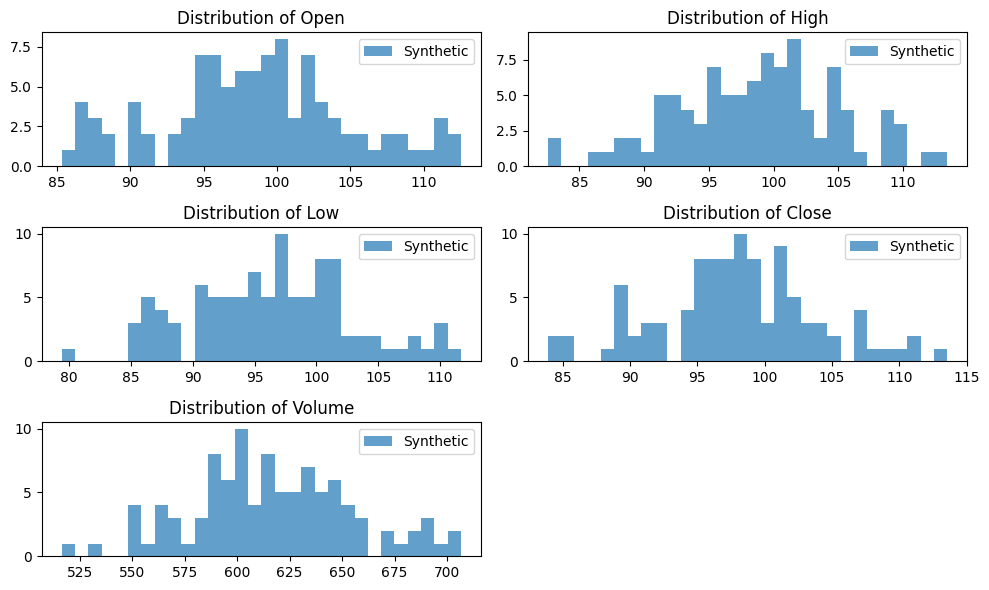

In [1]:
import os
import requests
import certifi
import pandas as pd
import yfinance as yf
from io import StringIO
from typing import List, Dict, Tuple
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import random
import matplotlib.pyplot as plt

import sys
from pathlib import Path

import os

# Set the working directory to the root of the project
os.chdir(Path('..').resolve())  # Adjust this path as necessary

# Now append the src directory to the path
import sys
sys.path.append(str(Path('src').resolve()))

import numpy as np
import pandas as pd
# Now import the necessary modules
from config import Config
import argparse
import logging
from pathlib import Path
from config import Config, setup_logging
from model import get_models
from data_loader import (
    StockDataset,
    download_stock_data,
    get_sp500_tickers,
    prepare_data,
    create_dataloader
)
from trainer import GANTrainer
from evaluation import (
    generate_synthetic_data,
    evaluate_quality,
    plot_results,
    plot_training_history,
    analyze_distributions
)
# Initialize configuration and check the data directory
config = Config()
print(f"Data directory: {config.DATA_DIR}")

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Fetch S&P 500 tickers and download stock data
# tickers = get_sp500_tickers(config)
# stock_data = download_stock_data(tickers, config)
# stock_data

# Step 2: Custom Dataset for Stock Data (with all features)
class StockDataset(Dataset):
    def __init__(self, data: Dict[str, pd.DataFrame]):
        """
        Initialize the dataset with historical stock data.
        """
        config = Config()
        self.data = []
        for ticker, df in data.items():
            # Convert all features to a 2D array with shape (n_samples, n_features)
            features = df[['Open', 'High', 'Low', 'Close', 'Volume']].values
            self.data.extend(features)
        self.data = torch.tensor(self.data, dtype=torch.float32).to(config.DEVICE)

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.data[idx]

# Step 3: Wasserstein GAN with Xavier Initialization
class WGANGenerator(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        """
        WGAN Generator with Xavier initialization and Batch Normalization.
        """
        super(WGANGenerator, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.relu(self.bn1(self.fc1(x)))
        return self.fc2(x)

class WGANDiscriminator(nn.Module):
    def __init__(self, input_size: int = 5, hidden_size: int = 256):
        """
        WGAN Discriminator with weight clipping.
        """
        super(WGANDiscriminator, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)
        self.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Step 4: Custom Differential Privacy Implementation
class DifferentialPrivacy:
    def __init__(self, epsilon: float, delta: float):
        """
        Initialize the custom differential privacy mechanism with specified parameters.
        """
        self.epsilon = epsilon
        self.delta = delta
        self.sensitivity = 1.0

    def apply_gradient_noise(self, gradients: torch.Tensor) -> torch.Tensor:
        """
        Apply Laplace noise to gradients to ensure differential privacy.
        """
        config = Config()
        noise = torch.distributions.laplace.Laplace(0, self.sensitivity / self.epsilon).sample(gradients.size()).to(config.DEVICE)
        return gradients + noise

# Step 5: Training WGAN with Differential Privacy
def train_wgan_with_dp(generator, discriminator, data_loader, dp_mechanism, epochs=10):
    """
    Train the WGAN with differential privacy by adding noise to gradients.
    """
    config = Config()
    optimizer_g = optim.Adam(generator.parameters(), lr=0.0002)  # Slightly increase generator learning rate
    optimizer_d = optim.Adam(discriminator.parameters(), lr=0.00001)  # Further reduce discriminator learning rate
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        for batch in data_loader:
            batch = batch.to(config.DEVICE)

            # Training discriminator
            optimizer_d.zero_grad()
            real_labels = discriminator(batch)
            noise = torch.randn(batch.size(0), 100).to(config.DEVICE)  # Generate noise of shape (batch_size, 100)
            fake_data = generator(noise)
            fake_labels = discriminator(fake_data.detach())

            d_loss = -(torch.mean(real_labels) - torch.mean(fake_labels))
            d_loss.backward()

            # Apply gradient noise for differential privacy
            for param in discriminator.parameters():
                param.grad = dp_mechanism.apply_gradient_noise(param.grad)

            optimizer_d.step()

            # Clip weights of discriminator to satisfy WGAN's constraints (loosen clipping bounds)
            for p in discriminator.parameters():
                p.data.clamp_(-0.05, 0.05)

            # Training generator
            optimizer_g.zero_grad()
            fake_labels = discriminator(fake_data)
            g_loss = -torch.mean(fake_labels)
            g_loss.backward()

            # Apply gradient noise for differential privacy
            for param in generator.parameters():
                param.grad = dp_mechanism.apply_gradient_noise(param.grad)

            optimizer_g.step()

        print(f"Epoch [{epoch+1}/{epochs}], D Loss: {d_loss.item()}, G Loss: {g_loss.item()}")


# Step 6: Generate Synthetic Data and Evaluate
def generate_and_evaluate(generator, num_samples: int = 100):
    """
    Generate synthetic data using the trained generator and evaluate the quality by comparing with real data.
    """
    config = Config()
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(num_samples, 100).to(config.DEVICE)
        synthetic_data = generator(noise).cpu().numpy()

    # Display basic statistics of generated synthetic data
    print("Synthetic Data Statistics:")
    print(f"Mean: {np.mean(synthetic_data, axis=0)}")
    print(f"Variance: {np.var(synthetic_data, axis=0)}")

    # You can also use PCA or t-SNE to visualize real
        # You can also use PCA or t-SNE to visualize real vs. synthetic data
    plt.figure(figsize=(10, 6))

    # Visualizing the distribution of synthetic vs real data using histograms for each feature
    for i, feature in enumerate(['Open', 'High', 'Low', 'Close', 'Volume']):
        plt.subplot(3, 2, i + 1)
        plt.hist(synthetic_data[:, i], bins=30, alpha=0.7, label='Synthetic')
        plt.title(f'Distribution of {feature}')
        plt.legend()

    plt.tight_layout()
    plt.show()
    
    return synthetic_data

# Step 7: Main Function to Drive the Project
# def main():
config = Config()

tickers = get_sp500_tickers(config)
stock_data = download_stock_data(tickers, config)
dataset = StockDataset(stock_data)
data_loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Initialize WGAN models with Xavier initialization
generator = WGANGenerator(input_size=100, hidden_size=256, output_size=5).to(config.DEVICE)  # 5 output features
discriminator = WGANDiscriminator(input_size=5, hidden_size=256).to(config.DEVICE)

# Initialize the custom differential privacy mechanism
dp_mechanism = DifferentialPrivacy(epsilon=1.0, delta=1e-5)

# Train WGAN with differential privacy
train_wgan_with_dp(generator, discriminator, data_loader, dp_mechanism, epochs=10)

# Generate and evaluate synthetic data
synth_data = generate_and_evaluate(generator, num_samples=100)

# if __name__ == "__main__":
#     main()


In [9]:
from sklearn.decomposition import PCA
import seaborn as sns

def generate_and_compare(generator, real_data: pd.DataFrame, num_samples: int = 100):
    """
    Generate synthetic data and compare it with real data to check for representativeness.
    Uses histograms for distribution comparisons and PCA for visual comparison.
    
    Args:
        generator: Trained GAN generator model.
        real_data (pd.DataFrame): Original real stock data.
        num_samples (int): Number of synthetic samples to generate.

    Returns:
        np.ndarray: Generated synthetic data array.
    """
    config = Config()
    generator.eval()
    with torch.no_grad():
        # Generate synthetic data
        noise = torch.randn(num_samples, 100).to(config.DEVICE)
        synthetic_data = generator(noise).cpu().numpy()
    
    # Convert synthetic data to DataFrame for easier comparison
    synthetic_df = pd.DataFrame(synthetic_data, columns=real_data.columns)

    # Plot distribution comparisons for each feature
    plt.figure(figsize=(15, 10))
    for i, feature in enumerate(real_data.columns):
        plt.subplot(2, 3, i + 1)
        sns.histplot(real_data[feature], color='blue', label='Real', kde=True, bins=20)
        sns.histplot(synthetic_df[feature], color='orange', label='Synthetic', kde=True, bins=20)
        plt.title(f'Distribution of {feature}')
        plt.legend()
    plt.tight_layout()
    plt.show()

    # Dimensionality reduction with PCA for visual comparison in 2D
    pca = PCA(n_components=2)
    real_data_sample = real_data.sample(num_samples)  # Ensure same size for PCA comparison
    combined_data = pd.concat([real_data_sample, synthetic_df], axis=0)
    pca_result = pca.fit_transform(combined_data)
    
    # Plot PCA results
    plt.figure(figsize=(8, 6))
    plt.scatter(pca_result[:num_samples, 0], pca_result[:num_samples, 1], color='blue', label='Real', alpha=0.5)
    plt.scatter(pca_result[num_samples:, 0], pca_result[num_samples:, 1], color='orange', label='Synthetic', alpha=0.5)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("PCA Comparison of Real vs. Synthetic Data")
    plt.legend()
    plt.show()

    return synthetic_df

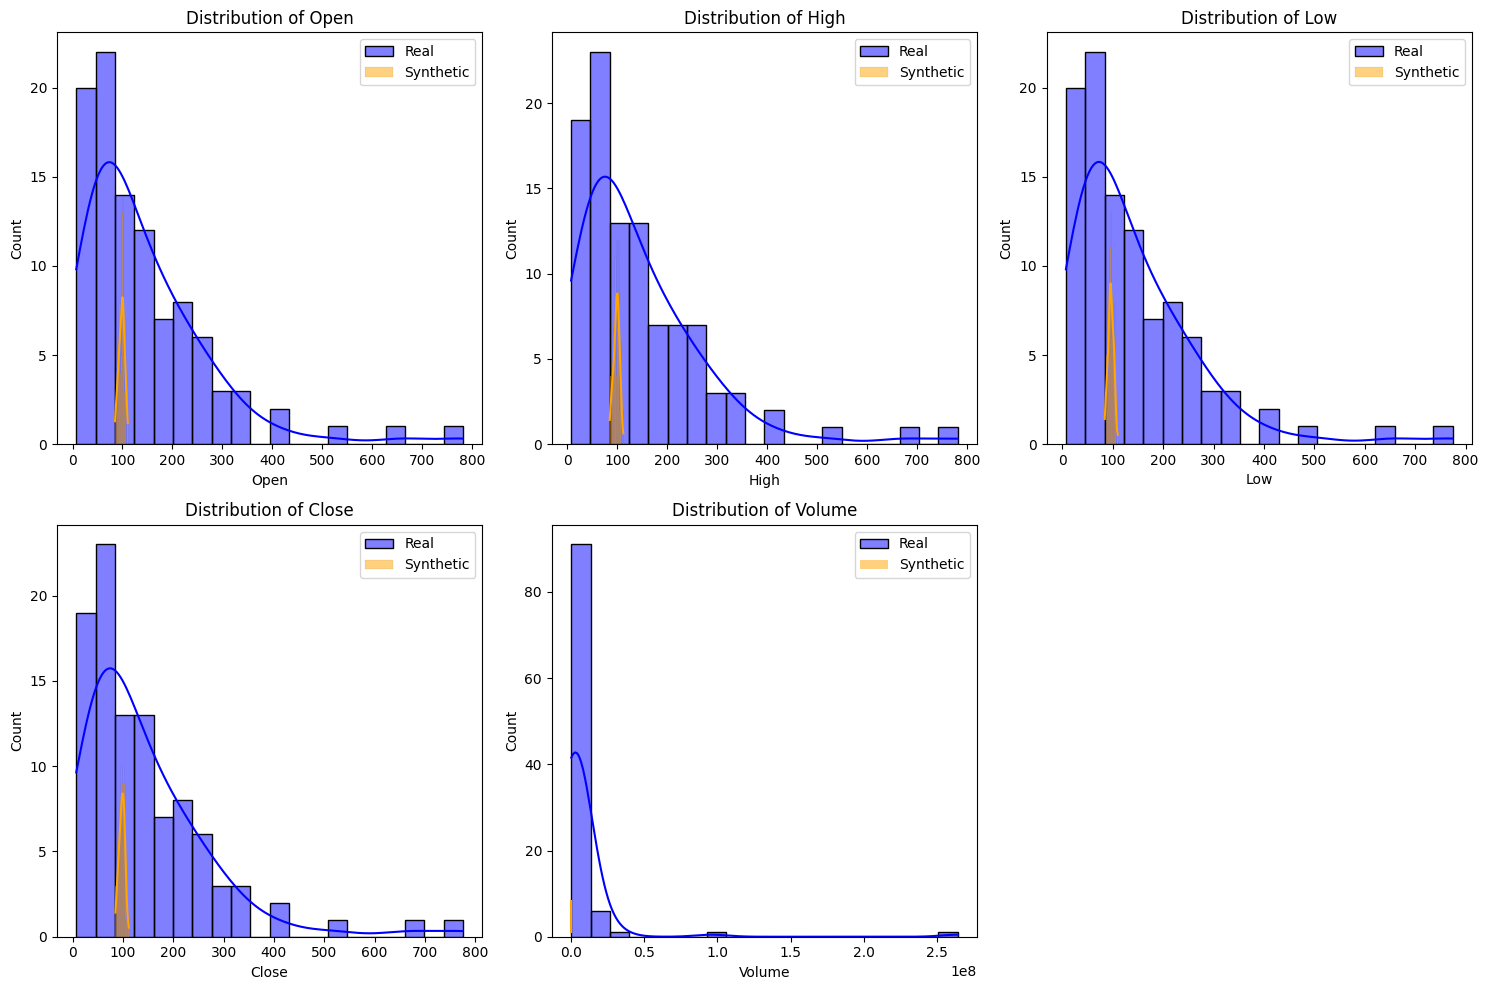

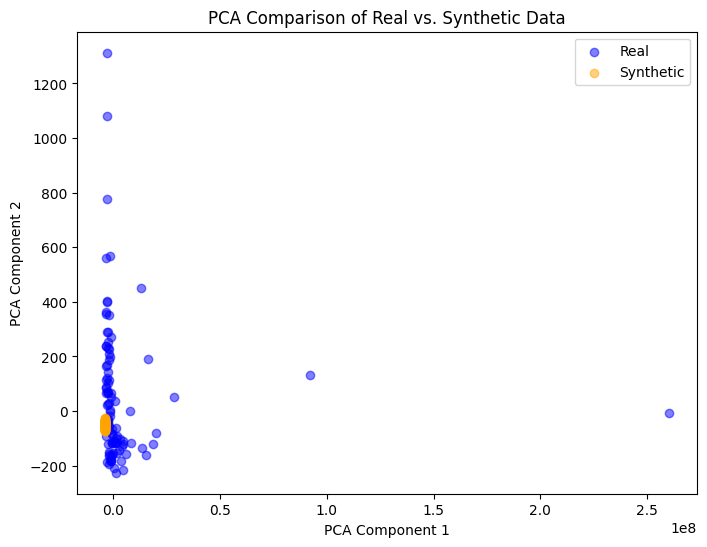

In [10]:
# Assuming `generator` is your trained generator and `stock_data` is a dictionary of real data DataFrames
real_data = pd.concat(stock_data.values()).sample(100)  # Sample a subset for comparison
synthetic_data = generate_and_compare(generator, real_data, num_samples=100)

In [ ]:
!

In [5]:
pd.DataFrame(synth_data, columns=real)

,0,1,2,3,4
0,90.902176,96.082893,88.347359,93.904007,582.324646
1,103.282471,102.568947,100.057762,104.112564,655.239136
2,93.061188,96.965492,94.623680,96.124008,599.924927
3,102.228966,108.091225,99.649467,104.809814,646.477661
4,103.886810,103.725960,100.391121,97.674911,652.190918
...,...,...,...,...,...
95,118.083244,115.409721,114.301849,121.412888,736.806641
96,98.486679,98.164574,97.582054,95.016998,616.489929
97,104.641457,108.152367,105.337364,104.599701,651.651123
98,101.811371,104.883553,100.756355,97.515060,647.607422


In [3]:
synth_data